## 03 - Modelling and Evaluating

### Objective

Answer Business Requirement 2:

- The client is interested to predict whether a cherry leaf is healthy or contains powdery mildew.

### Inputs

- inputs/cherry_leaves_split/train
- inputs/cherry_leaves_split/val
- inputs/cherry_leaves_split/test
- outputs/02_data_visualisation/image_shape.pkl

### Outputs

- Model saved as .h5
- Class indices saved as .pkl
- Learning curves
- Model evaluation score

### Imports

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from matplotlib.image import imread
from matplotlib.image import imread
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import backend as K

sns.set_style("whitegrid")

### Set Working Directory

In [2]:
os.chdir('C:/Users/Robert/mildew_cherry_detector')
print("Current directory:", os.getcwd())

Current directory: C:\Users\Robert\mildew_cherry_detector


### Set paths

In [3]:
cwd = os.getcwd()
print("Working directory set:", cwd)

train_path = "C:/Users/Robert/mildew_cherry_detector/inputs/cherry_leaves_split/train"
val_path = "C:/Users/Robert/mildew_cherry_detector/inputs/cherry_leaves_split/val"
test_path = "C:/Users/Robert/mildew_cherry_detector/inputs/cherry_leaves_split/test"

version = "03_modelling_and_evaluating"
file_path = f"outputs/{version}"
os.makedirs(file_path, exist_ok=True)

Working directory set: C:\Users\Robert\mildew_cherry_detector


### Labels and image shape

In [4]:
labels = os.listdir(train_path)
print("Project Labels:", labels)

image_shape = joblib.load("outputs/02_data_visualisation/image_shape.pkl")
print("Image shape:", image_shape)

Project Labels: ['healthy', 'powdery_mildew']
Image shape: (256, 256, 3)


### Image count distribution

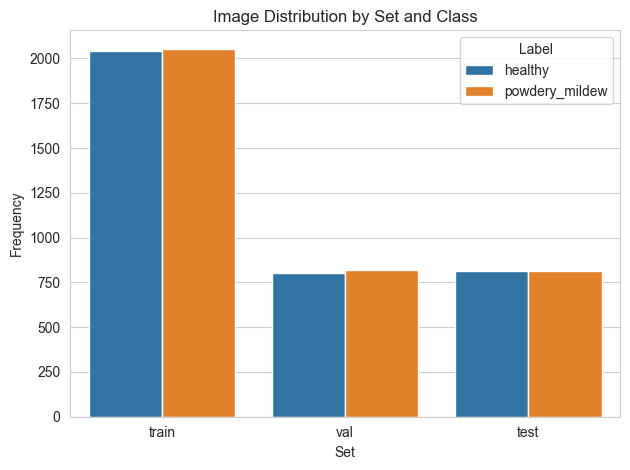

In [5]:
df_freq = pd.DataFrame()
for folder in ['train', 'val', 'test']:
    for label in labels:
        count = len(os.listdir(f"inputs/cherry_leaves_split/{folder}/{label}"))
        df_freq = pd.concat([df_freq, pd.DataFrame([{"Set": folder, "Label": label, "Frequency": count}])])

sns.barplot(data=df_freq, x='Set', y='Frequency', hue='Label')
plt.title("Image Distribution by Set and Class")
plt.tight_layout()
plt.savefig(f"{file_path}/labels_distribution.png", dpi=150)
plt.show()

### Image Augmentation

In [6]:
batch_size = 20

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_set = train_datagen.flow_from_directory(train_path, target_size=image_shape[:2], batch_size=batch_size, class_mode='binary')
val_set = val_test_datagen.flow_from_directory(val_path, target_size=image_shape[:2], batch_size=batch_size, class_mode='binary')
test_set = val_test_datagen.flow_from_directory(test_path, target_size=image_shape[:2], batch_size=batch_size, class_mode='binary')

Found 4098 images belonging to 2 classes.
Found 1626 images belonging to 2 classes.
Found 1627 images belonging to 2 classes.


### Preview augmented images

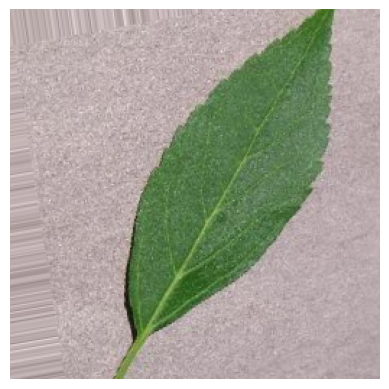

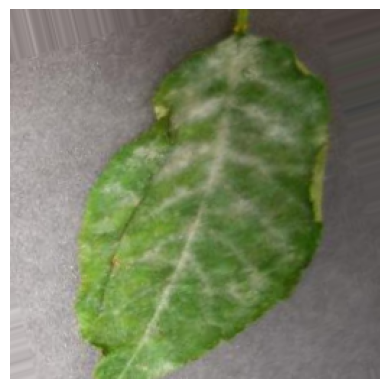

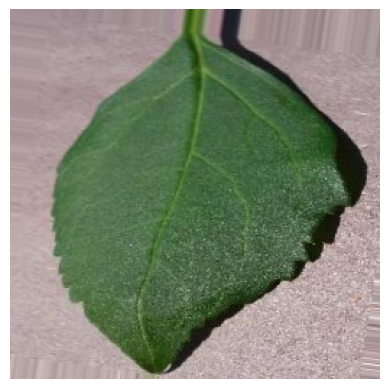

In [7]:
for _ in range(3):
    img, label = next(train_set)
    plt.imshow(img[0])
    plt.axis("off")
    plt.show()

### Save class indices

In [8]:
import os
import joblib

# Make sure the directory exists
os.makedirs(file_path, exist_ok=True)

# Save to the correct path
joblib.dump(train_set.class_indices, f"{file_path}/class_indices.pkl")

['outputs/03_modelling_and_evaluating/class_indices.pkl']

### Create CNN Model

In [9]:
def create_model():
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=image_shape),
        MaxPooling2D(2, 2),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])

    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

model = create_model()
model.summary()

c:\Users\Robert\miniforge3\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,429,377 (28.34 MB)

 Trainable params: 7,429,377 (28.34 MB)

 Non-trainable params: 0 (0.00 B)

### Train the model

In [10]:
early_stop = EarlyStopping(monitor='val_loss', patience=3)

history = model.fit(
    train_set,
    epochs=25,
    steps_per_epoch=len(train_set),
    validation_data=val_set,
    validation_steps=len(val_set),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/25
205/205 ━━━━━━━━━━━━━━━━━━━━ 47s 226ms/step - accuracy: 0.8748 - loss: 0.2758 - val_accuracy: 0.9975 - val_loss: 0.0318
Epoch 2/25
205/205 ━━━━━━━━━━━━━━━━━━━━ 41s 201ms/step - accuracy: 0.9883 - loss: 0.0357 - val_accuracy: 0.9988 - val_loss: 0.0043
Epoch 3/25
205/205 ━━━━━━━━━━━━━━━━━━━━ 44s 213ms/step - accuracy: 0.9873 - loss: 0.0426 - val_accuracy: 0.9969 - val_loss: 0.0088
Epoch 4/25
205/205 ━━━━━━━━━━━━━━━━━━━━ 44s 214ms/step - accuracy: 0.9871 - loss: 0.0477 - val_accuracy: 0.9957 - val_loss: 0.0090
Epoch 5/25
205/205 ━━━━━━━━━━━━━━━━━━━━ 45s 219ms/step - accuracy: 0.9900 - loss: 0.0325 - val_accuracy: 0.9920 - val_loss: 0.0195


### Save the model

In [11]:
model.save("C:/Users/Robert/mildew_cherry_detector/outputs/v1/cherry_leaf_mildew_model.h5")

### Learning Curves

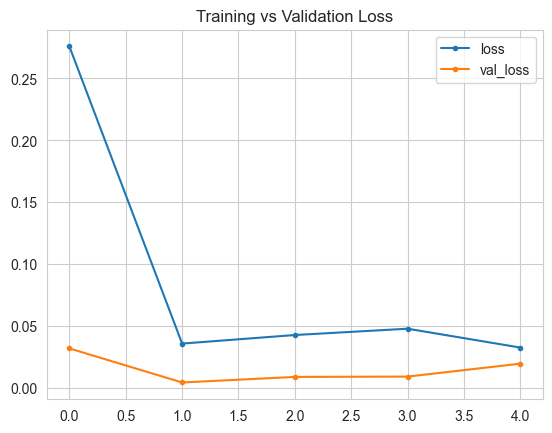

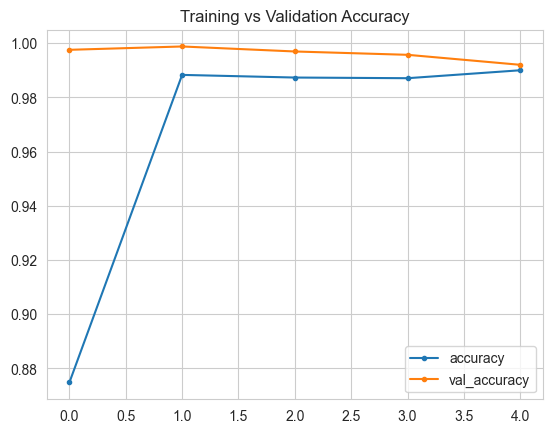

In [12]:
loss_df = pd.DataFrame(history.history)

loss_df[['loss', 'val_loss']].plot(style='.-')
plt.title("Training vs Validation Loss")
plt.savefig(f"{file_path}/training_loss.png", dpi=150)
plt.show()

loss_df[['accuracy', 'val_accuracy']].plot(style='.-')
plt.title("Training vs Validation Accuracy")
plt.savefig(f"{file_path}/training_accuracy.png", dpi=150)
plt.show()

### Evaluate on Test Set

In [13]:
K.clear_session()  # Clear previous model traces
model = load_model("C:/Users/Robert/mildew_cherry_detector/outputs/v1/cherry_leaf_mildew_model.h5")

test_eval = model.evaluate(test_set)
print("Test Set Evaluation (Loss, Accuracy):", test_eval)

joblib.dump(test_eval, "C:/Users/Robert/mildew_cherry_detector/outputs/v1/evaluation.pkl")

82/82 ━━━━━━━━━━━━━━━━━━━━ 9s 103ms/step - accuracy: 0.9908 - loss: 0.0233
Test Set Evaluation (Loss, Accuracy): [0.023344114422798157, 0.9907805919647217]


['C:/Users/Robert/mildew_cherry_detector/outputs/v1/evaluation.pkl']

### Predict on a random image

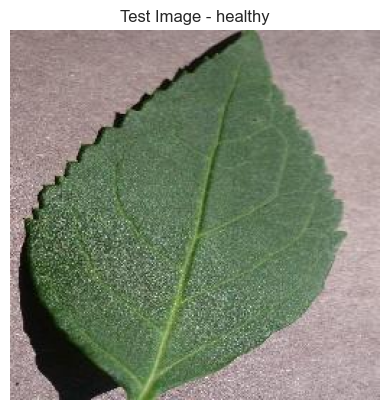

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Predicted: healthy (1.00 confidence)


In [14]:
def predict_image(model, image_path, class_map):
    img = load_img(image_path, target_size=image_shape[:2])
    arr = img_to_array(img) / 255.
    arr = np.expand_dims(arr, axis=0)
    prob = model.predict(arr)[0, 0]
    pred_class = class_map[int(prob > 0.5)]
    confidence = prob if pred_class == class_map[1] else 1 - prob
    return pred_class, confidence

pointer = 10
label = labels[0]
img_file = os.listdir(f"{test_path}/{label}")[pointer]
img_path = os.path.join(test_path, label, img_file)

plt.imshow(load_img(img_path))
plt.axis("off")
plt.title(f"Test Image - {label}")
plt.show()

class_map = {v: k for k, v in train_set.class_indices.items()}
pred, conf = predict_image(model, img_path, class_map)
print(f"Predicted: {pred} ({conf:.2f} confidence)")

### Push files to repo